In [1]:
import pandas as pd

df = pd.read_csv('silver_prices_data.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2011-01-24,27.318001,27.459999,26.955000,27.174999,168
1,2011-01-25,26.811001,26.950001,26.565001,26.915001,77
2,2011-01-26,27.132000,27.025000,26.684999,27.025000,49
3,2011-01-27,27.045000,27.684999,27.410000,27.684999,184
4,2011-01-28,27.934000,27.950001,26.504999,26.695000,64


In [2]:
df.info()
df.describe()
df.isnull().sum()

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3768 non-null   object 
 1   Close   3768 non-null   float64
 2   High    3768 non-null   float64
 3   Low     3768 non-null   float64
 4   Open    3768 non-null   float64
 5   Volume  3768 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 176.8+ KB


In [8]:
from sklearn.preprocessing import StandardScaler

df.ffill(inplace=True)

df['Target'] = (df['Close'] > df['Open']).astype(int)

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Show output
print("Sample Features:\n", X[:5])
print("Sample Target:\n", y.head())

Sample Features:
 [[ 0.4230677   0.42681119  0.42734822 -0.16154563]
 [ 0.39310482  0.36914955  0.38157133 -0.17046716]
 [ 0.40578136  0.3776291   0.39565642 -0.17321225]
 [ 0.48184143  0.45225027  0.48075466 -0.15997701]
 [ 0.36775132  0.48221195  0.37452856 -0.17174167]]
Sample Target:
 Date
2011-01-24    1
2011-01-25    0
2011-01-26    1
2011-01-27    0
2011-01-28    1
Name: Target, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model with more iterations
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Show output
print("Model Trained Successfully")
print("First 5 Predictions:", y_pred[:5])

Model Trained Successfully
First 5 Predictions: [0 0 0 0 0]


Accuracy: 0.7148541114058355

Confusion Matrix:
 [[401  23]
 [192 138]]

Report:
               precision    recall  f1-score   support

           0       0.68      0.95      0.79       424
           1       0.86      0.42      0.56       330

    accuracy                           0.71       754
   macro avg       0.77      0.68      0.68       754
weighted avg       0.76      0.71      0.69       754



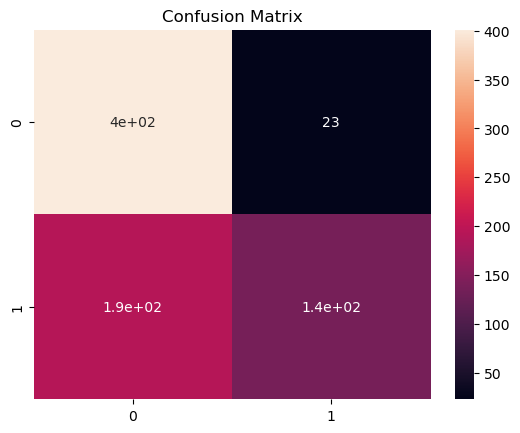

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

# Confusion Matrix Graph
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title("Confusion Matrix")
plt.show()